In [1]:
import numpy as np, matplotlib.pyplot as plt, seaborn as sns, pandas as pd
from pathlib import Path

Сгенерируй 10000 значений роста взрослых людей: нормальное с μ=170, σ=10. Построй гистограмму. Посмотри на форму.

<Axes: ylabel='Count'>

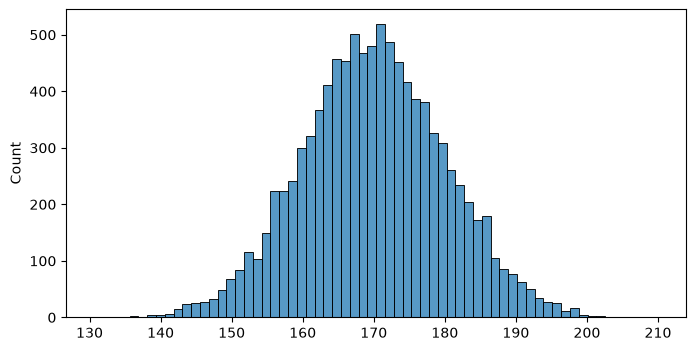

In [2]:
mu = 170
sigma = 10
heights = np.random.normal(mu, sigma, 10000)

fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=heights)

Не трогая σ, поставь μ=190. Потом верни μ=170 и поставь σ=30. Скажи словами, что делает с картинкой каждый параметр.

<Axes: ylabel='Count'>

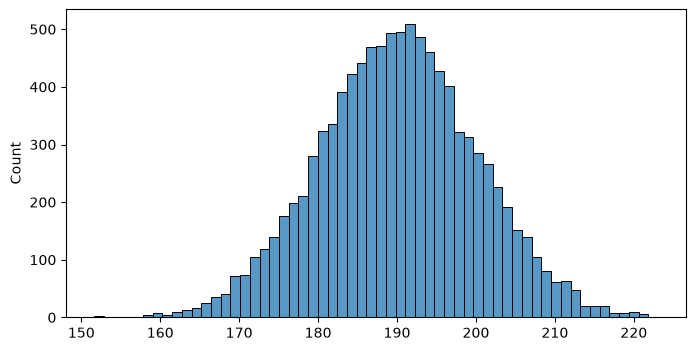

In [3]:
mu = 190
heights = np.random.normal(mu, sigma, 10000)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=heights)

По гистограмме видно, что, изменив мю на 190, мы просто поменяли среднее значение или просто подвинули график на 20 единиц вправо

<Axes: ylabel='Count'>

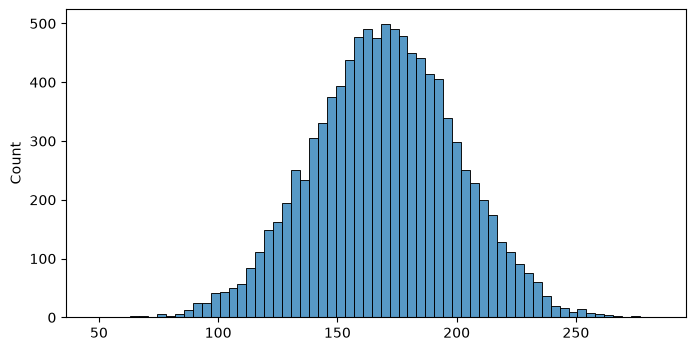

In [4]:
mu = 170
sigma = 30
heights = np.random.normal(mu, sigma, 10000)
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=heights)

По графику видно что он стал шире, то есть увеличив сигму мы увеличили разброс

Вывод: мю - среднее значение, сигма - разброс

На исходной выборке (μ=170, σ=10) посчитай доли значений, попавших в промежутки:

от μ−σ до μ+σ
от μ−2σ до μ+2σ
от μ−3σ до μ+3σ

в первом случае мы получим 68 процентов всех наблюдений, во втором 95, а в третьем 100

In [5]:
print(np.sum((heights >= mu - sigma) & (heights <= mu + sigma)) / 100)
print(np.sum((heights >= mu - 2 * sigma) & (heights <= mu + 2 * sigma)) / 100)
print(np.sum((heights >= mu - 3 * sigma) & (heights <= mu + 3 * sigma)) / 100)

68.05
95.41
99.73


результаты не совпали точ в точ так как для этого потребывалось количество эллементов устремить в бесконечность (решил не делить на 10000 а потом умножать 100, а скоратить и просто делить на 100)

Найди значения дальше 3σ от среднего. Сколько их из 10000? Совпадает ли доля с тем, что ты получил в задаче 3?

In [6]:
print(len(heights[(heights < mu - 3 * sigma) | (heights > mu + 3 * sigma)]))
print(len(heights[(heights < mu - 3 * sigma) | (heights > mu + 3 * sigma)]) / 100)

27
0.27


Всего их 35, доля совпадает с прошлой задачей

Теперь на реальных данных. Возьми fare из Titanic и примени то же правило: посчитай долю пассажиров в пределах ±1σ, ±2σ, ±3σ от среднего fare.

In [7]:
Path("../data").mkdir(parents=True, exist_ok=True)
df = sns.load_dataset('titanic')
df.to_csv('../data/titanic.csv', index=False)

mu_fare_titanic = df['fare'].mean()
sigma_fare_titanic = (df['fare'].var())**(0.5)
print(np.sum((df['fare'] >= mu_fare_titanic - sigma_fare_titanic) & (df['fare'] <= mu_fare_titanic + sigma_fare_titanic)) / len(df['fare']) * 100)
print(np.sum((df['fare'] >= mu_fare_titanic - 2 * sigma_fare_titanic) & (df['fare'] <= mu_fare_titanic + 2 * sigma_fare_titanic)) / len(df['fare']) * 100)
print(np.sum((df['fare'] >= mu_fare_titanic - 3 * sigma_fare_titanic) & (df['fare'] <= mu_fare_titanic + 3 * sigma_fare_titanic)) / len(df['fare']) * 100)

91.80695847362514
95.7351290684624
97.75533108866442


Не сходится с 3, предполога что причина в том, что распределение цен не нормальное

Посчитай для age сам и убедись, что мои числа сходятся с твоими.

In [8]:
mu_age_titanic = df['age'].mean()
sigma_age_titanic = df['age'].var()**(0.5)
print(mu_age_titanic, sigma_age_titanic)
print(np.sum((df['age'] >= mu_age_titanic - sigma_age_titanic) & (df['age'] <= mu_age_titanic + sigma_age_titanic)) / df['age'].count() * 100)
print(np.sum((df['age'] >= mu_age_titanic - 2 * sigma_age_titanic) & (df['age'] <= mu_age_titanic + 2 * sigma_age_titanic)) / df['age'].count() * 100)
print(np.sum((df['age'] >= mu_age_titanic - 3 * sigma_age_titanic) & (df['age'] <= mu_age_titanic + 3 * sigma_age_titanic)) / df['age'].count() * 100)

29.69911764705882 14.526497332334042
72.26890756302521
95.93837535014006
99.71988795518207


Да, действительно, видно что возраст распределен нормально

Сравни для обеих колонок среднее и медиану:

In [9]:
median_fare_titanic = df['fare'].median()
median_age_titanic = df['age'].median()
print(f"fare: среднее {mu_fare_titanic}, медиана {median_fare_titanic}")
print(f"age: среднее {mu_age_titanic}, медиана {median_age_titanic}")

fare: среднее 32.204207968574636, медиана 14.4542
age: среднее 29.69911764705882, медиана 28.0


fare у которого не нормальное распределение медиана сильно меньше чем среднее, когда у age они равны и у этого столбца нормальное распределение
Также можно заменить что у fare медиана меньше среднего это значит что количество эллементов, которые меньше среднего сильно больше чем тех что больше среднего, это значит что в таком случае у распределения будет длинный хвост слева, а если медиана сильно больше среднего, по тому же принципу длинный хвост будет находится справа, а если медина равна среднему это значит что элементов, которые больше среднего, столько же, сколько эллементов, которые меньше среднего, что означает, что длинного хвоста с какой то стороны не будет, они будут равны

<Axes: xlabel='fare', ylabel='Count'>

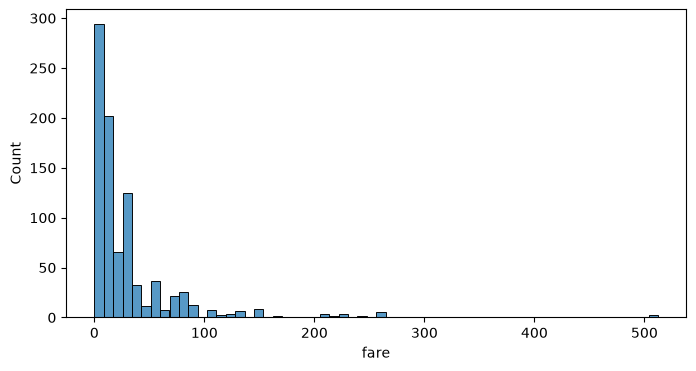

In [10]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df['fare'])

<Axes: xlabel='age', ylabel='Count'>

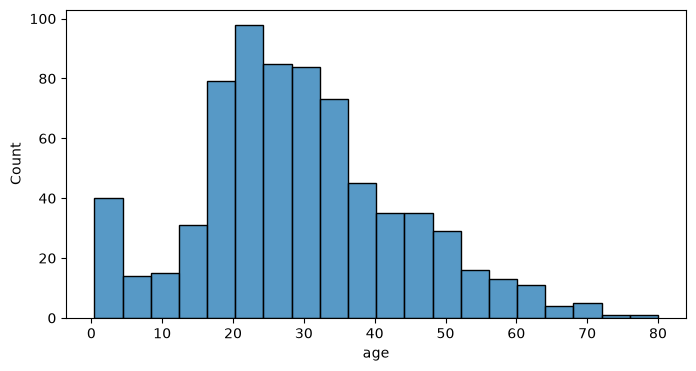

In [11]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=df['age'])

я вывел не правильное правило на счёт правого и левого хвоста
длинный хвост появляется справа когда медиана меньше среднего как у fare, потому что раз медиана слева от среднего заначения это значит что справа есть выбросы,
анологично если медиана больше среднего, значит длиный хвост будет слева

Правый хвост часто выпрямляют логарифмированием. Построй гистограмму np.log1p(df['fare']) и сравни с исходной. Посчитай для логарифма среднее и медиану — насколько они сблизились?

<Axes: xlabel='fare', ylabel='Count'>

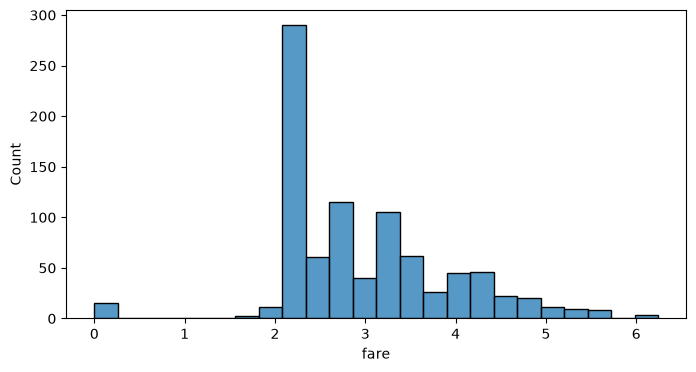

In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=np.log1p(df['fare']))

Как по мне график не сильно отличается от предыдущего, всё равно видно длинный хвост справа

In [13]:
log_median_fare = np.median(np.log1p(df['fare']))
log_mean_fare = np.mean(np.log1p(df['fare']))
print(log_median_fare, log_mean_fare)
print(f"Разница = {log_mean_fare - log_median_fare}")
print(pd.Series(np.log1p(df['fare'])).skew())

2.737880811060884 2.9622457416890815
Разница = 0.22436493062819762
0.3949280095189306


Они сблизились очень сильно, разница между ними примерно 0.22, а skew показал почти 0.4

Подумай и ответь словами: зачем логарифмировать признак перед обучением модели? Подсказка — вспомни, что ты делал с признаками перед моделью в задании по numpy и зачем.

Чтобы привести данные к общей единице измерения, чтобы для модели видели разницу между 70 и 10 в возрасте также как разницу между 100 700 в ценах на билет
Логарифм сжимает выбросы сильнее обычных эллементов, что приводит к тому что отдельные объекты перестают весить в кучу раз больше других, также логарифм связь становится линейной

Задача:
Для n = 2

<Axes: ylabel='Count'>

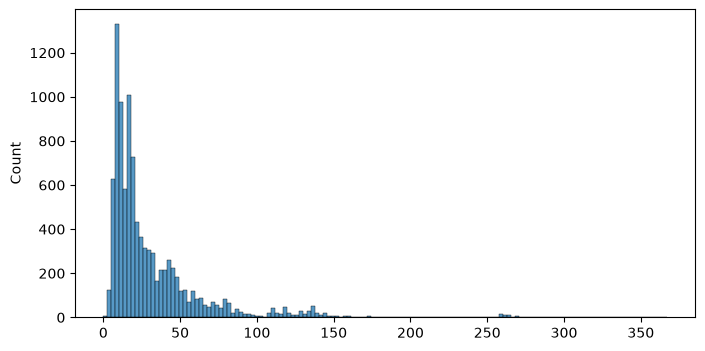

In [14]:
n = 2
means = []
for _ in range(10000):
    choice = np.random.choice(df['fare'], size=n, replace=True)
    means.append(choice.mean())

n2_mean = np.mean(means)
n2_std = np.std(means)
n2_skew = pd.Series(means).skew()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=means)

По графику видно что график средних напоминает график fare

Для n = 5

<Axes: ylabel='Count'>

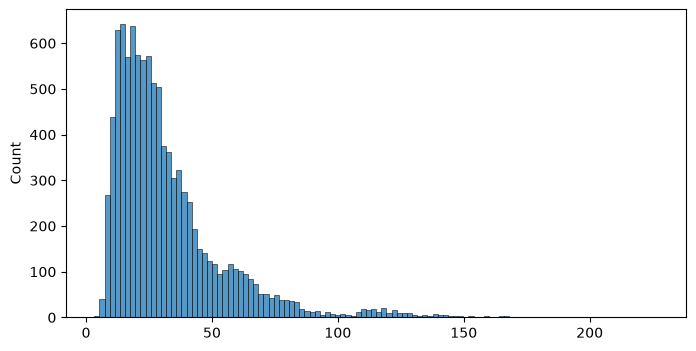

In [15]:
n = 5
means = []
for _ in range(10000):
    choice = np.random.choice(df['fare'], size=n, replace=True)
    means.append(choice.mean())

n5_mean = np.mean(means)
n5_std = np.std(means)
n5_skew = pd.Series(means).skew()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=means)

При n = 5 можно заметить как график чуть выпрямился в правую сторону

Для n = 30

<Axes: ylabel='Count'>

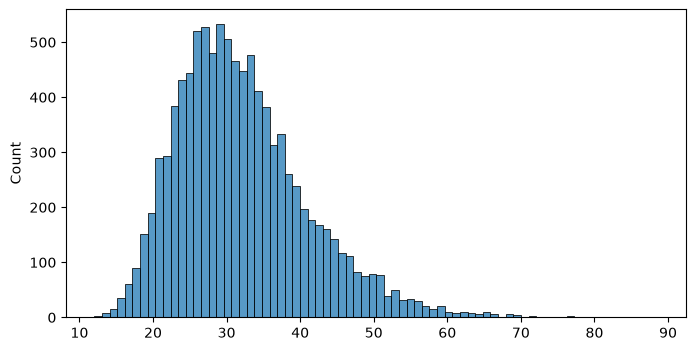

In [16]:
n = 30
means = []
for _ in range(10000):
    choice = np.random.choice(df['fare'], size=n, replace=True)
    means.append(choice.mean())

n30_mean = np.mean(means)
n30_std = np.std(means)
n30_skew = pd.Series(means).skew()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=means)

При n = 30 график продолжил выпрямлсятся вправо и начал принимать образы нормального распределения но всё еще виднеется маленькая ассиметрия

Для n = 100

<Axes: ylabel='Count'>

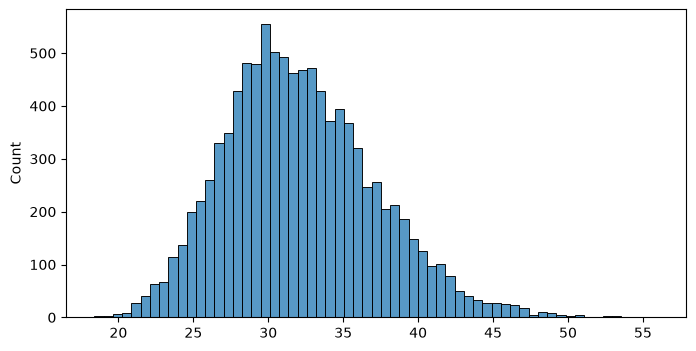

In [17]:
n = 100
means = []
for _ in range(10000):
    choice = np.random.choice(df['fare'], size=n, replace=True)
    means.append(choice.mean())

n100_mean = np.mean(means)
n100_std = np.std(means)
n100_skew = pd.Series(means).skew()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=means)

Для n = 400

<Axes: ylabel='Count'>

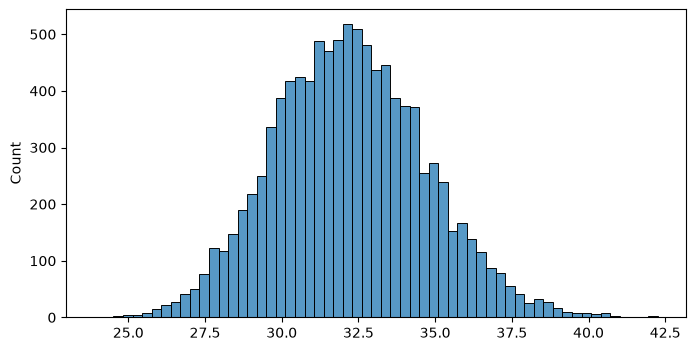

In [18]:
n = 400
means = []
for _ in range(10000):
    choice = np.random.choice(df['fare'], size=n, replace=True)
    means.append(choice.mean())

n400_mean = np.mean(means)
n400_std = np.std(means)
n400_skew = pd.Series(means).skew()
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=means)

In [19]:
fare_std = np.std(df['fare'])
s = []
for n_std in [n2_std, n5_std, n30_std, n100_std, n400_std, np.std(df['fare'])]:
    s.append(fare_std / n_std)

df_ns = pd.DataFrame({
    's': s,
    'mean': [n2_mean, n5_mean, n30_mean, n100_mean, n400_mean, np.mean(df['fare'])],
    'std': [n2_std, n5_std, n30_std, n100_std, n400_std, np.std(df['fare'])],
    'skew': [n2_skew, n5_skew, n30_skew, n100_skew, n400_skew, df['fare'].skew()]
},
    index=['n = 2', 'n = 5', 'n = 30', 'n = 100', 'n = 400', 'fare']
)

df_ns

,s,mean,std,skew
n = 2,1.463235,31.497178,33.942275,3.306570
n = 5,2.208449,32.140633,22.488880,2.188811
n = 30,5.568598,32.065319,8.918858,0.912839
n = 100,9.933205,32.119238,4.999950,0.490906
n = 400,20.124589,32.214285,2.467903,0.183511
fare,1.000000,32.204208,49.665534,4.787317


Распределение средних приблизилось к нормальному очень сильно, что можно увидеть по таблце,
Среднее по мере роста n почти не менялось и не отличалось от среднего fare,
Стандартное отклонение уменьшалось по мере роста n,
По мере роста n распределение становилось всё симметричнее,
Чтобы уменьшить стандартное отклонение в 2 раза надо увелечить n в 4 раза, это видно по строкам n = 100 и n = 400, для того чтобы понять как именно друг от друга зависят эти числа посмотрю для n = 3600

59.834588933610405
0.8300472240208854


<Axes: ylabel='Count'>

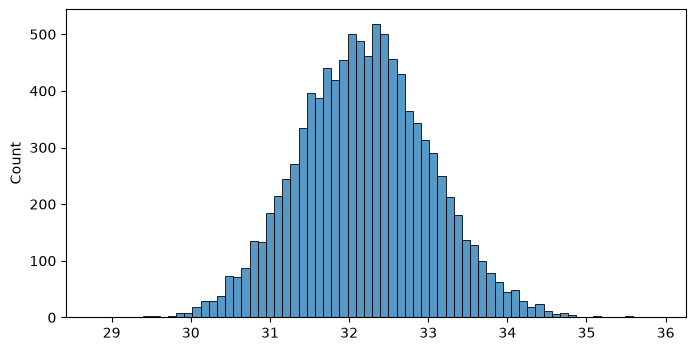

In [20]:
n = 3600
means = []
for _ in range(10000):
    choice = np.random.choice(df['fare'], size=n, replace=True)
    means.append(choice.mean())

print(fare_std / np.std(means))
print(np.std(means))
fig, ax = plt.subplots(figsize=(8, 4))
sns.histplot(data=means)

Я увеличил n в 9 раз а std уменьшил в 3 раза значит для того чтобы уменьшить std в x раз нужно увеличить n в x**2 раз

Задача 1:
Предсказываю что разброс будет маленький ведь SE получится маленьким

In [21]:
p = 1/11
n = 11
SE = (p * (1 - p) / n)**0.5
print(SE)
print(p - 2 * SE, p + 2 * SE)

0.08667841720414475
-0.08244774349919859 0.2642659253173804


Интервал получился большой, конец втрое больше SE

Задача 2: Твоя модель дала accuracy 0.87, чужая 0.89. Тест — 200 объектов.

Посчитай SE для обеих долей. Сравни разницу между моделями (0.02) с величиной SE.

In [22]:
n = 200
p1 = 0.87
SE1 = (p1 * (1 - p1) / n)**0.5
print(SE1)
print(p1 - 2 * SE1, p1 + 2 * SE1)
p2 = 0.89
SE2 = (p2 * (1 - p2) / n)**0.5
print(SE2)
print(p2 - 2 * SE2, p2 + 2 * SE2)

0.02378024390118823
0.8224395121976236 0.9175604878023764
0.022124646889837583
0.8457507062203249 0.9342492937796751


Видно что разброс средних в ходит в друг друга, отсюда можно сделать вывод что разница между двумя средними не говорит о более лучшем поведении модели

Задача 3:
думаю в 1 будет маленький разброс, когда у 2 будет большой

In [23]:
n1 = df[(df['pclass'] == 2) & (df['embarked'] == 'Q')].shape[0]
p1 = df[(df['pclass'] == 2) & (df['embarked'] == 'Q')]['survived'].mean()
SE1 = (p1 * (1 - p1) / n1)**0.5
n2 = df[(df['sex'] == 'male') & (df['pclass'] == 3)].shape[0]
p2 = df[(df['sex'] == 'male') & (df['pclass'] == 3)]['survived'].mean()
SE2 = (p2 * (1 - p2) / n2)**0.5
print(p1 - 2 * SE1, p1 + 2 * SE1)
print(p2 - 2 * SE2, p2 + 2 * SE2)

0.12233561271484927 1.2109977206184839
0.09870616240305403 0.17218720935487103


1 ширина интервала практически нулевая, когда во 2 конец в двое больше начала